In [1]:
import numpy as np
from scipy.constants import R
import matplotlib.pyplot as plt

from LJ_gas import (
    ParticleSystem, SimulationParameters,
    simulate_NVT_step, initialize_positions, initialize_velocities,
    calculate_force, potential_energy, kinetic_energy,
    instantaneous_temperature, density,
)

# argon params
mass_argon = 39.95
sigma_argon = 0.34            # nm
epsilon_argon = 120 * R * 1e-3   # kJ/mol

print("imports ok")

imports ok


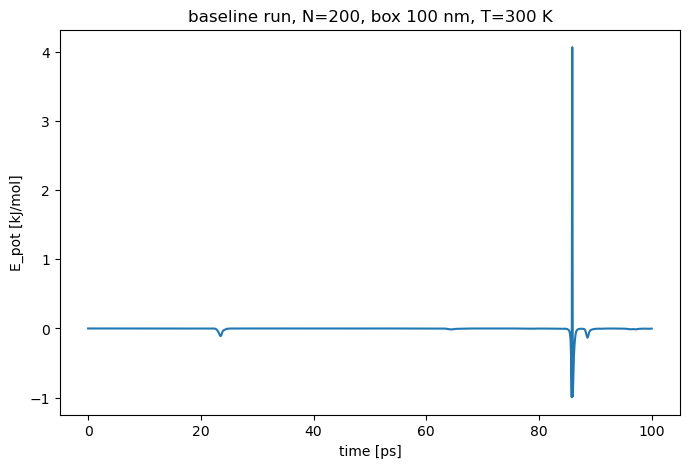

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# load the energy data the run saved. columns: E_pot, E_kin, T, P
ene = np.load("baseline_ene.npy")

dt = 0.1  # ps, same as in the run script
t = np.arange(ene.shape[0]) * dt  # time axis

# potential energy, no forced y limits this time
plt.figure(figsize=(8, 5))
plt.plot(t, ene[:, 0])
plt.xlabel("time [ps]")
plt.ylabel("E_pot [kJ/mol]")
plt.title("baseline run, N=200, box 100 nm, T=300 K")
plt.savefig("baseline_Epot_clean.png", dpi=200, bbox_inches="tight")
plt.show()

baseline run at defaults. E_pot sits at ~0 almost the whole time because the box
is huge and particles rarely meet. spikes = rare close encounters. not exploding,
not flat from being broken - flat because dilute..


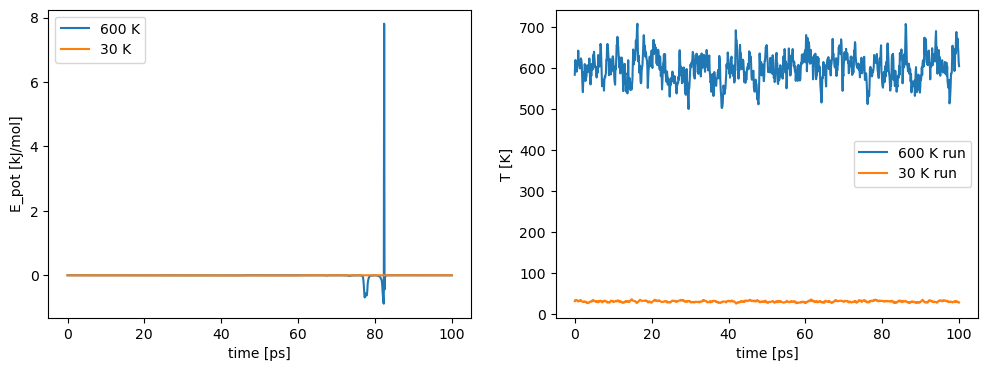

In [3]:
# compare E_pot for hot vs cold run
hot = np.load("hot_600K_ene.npy")
cold = np.load("cold_30K_ene.npy")
t = np.arange(hot.shape[0]) * 0.1  # ps

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t, hot[:, 0], label="600 K")
ax[0].plot(t, cold[:, 0], label="30 K")
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("E_pot [kJ/mol]")
ax[0].legend()

# temperature check - did the thermostat actually hold the targets
ax[1].plot(t, hot[:, 2], label="600 K run")
ax[1].plot(t, cold[:, 2], label="30 K run")
ax[1].set_xlabel("time [ps]")
ax[1].set_ylabel("T [K]")
ax[1].legend()

plt.savefig("hot_vs_cold.png", dpi=200, bbox_inches="tight")
plt.show()

hot 600 K vs cold 30 K at default density. E_pot flat at 0 for both, one lucky
collision in the hot run at ~82 ps. no clumping even at 30 K (argon boils at 87 K)
because the box is 100000x too dilute - particles never find each other.
thermostat confirmed working: T holds at both targets, bigger fluctuations at
600 K which is expected (fluctuation size scales with T).
conclusion for the project: condensation needs higher density. temperature alone
does nothing at this density